In [1]:
# 如果 python 版本 >3.12 ，请将下行注释掉，否则 matplotlib 不会显示图像
# %matplotlib inline
%time from hikyuu.interactive import *
iodog.open()

import matplotlib

# 设置中文字体为黑体
matplotlib.rcParams['font.sans-serif'] = 'SimHei'

2026-04-22 15:41:59,103 [INFO] runing in interactive session [<module>] (C:\Users\Zhi\AppData\Local\miniconda3\Lib\site-packages\hikyuu\__init__.py:145) [hikyuu::hku_info]
2026-04-22 15:41:59,105 [INFO] running in jupyter [<module>] (C:\Users\Zhi\AppData\Local\miniconda3\Lib\site-packages\hikyuu\__init__.py:152) [hikyuu::hku_info]


2026-04-22 15:41:59.122 [HKU-I] - 插件路径: C:\Users\Zhi\AppData\Local\miniconda3\Lib\site-packages\hikyuu_plugin (StockManager.cpp:110)
2026-04-22 15:41:59.159 [HKU-I] - Using SQLITE3 BaseInfoDriver (BaseInfoDriver.cpp:56)
2026-04-22 15:41:59.162 [HKU-I] - 加载市场信息…… (StockManager.cpp:795)
2026-04-22 15:41:59.162 [HKU-I] - 加载证券类型信息…… (StockManager.cpp:812)
2026-04-22 15:41:59.163 [HKU-I] - 加载证券信息…… (StockManager.cpp:693)
2026-04-22 15:41:59.339 [HKU-I] - 加载权息数据…… (StockManager.cpp:829)
2026-04-22 15:41:59.514 [HKU-I] - 加载板块信息…… (StockManager.cpp:184)
2026-04-22 15:41:59.561 [HKU-I] - 加载K线数据…… (StockManager.cpp:188)
2026-04-22 15:41:59.562 [HKU-I] - 预加载 month K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-04-22 15:41:59.563 [HKU-I] - 预加载 day K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-04-22 15:41:59.563 [HKU-I] - 预加载 week K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-04-22 15:41:59.564 [HKU-I] - 预加载 year K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-04-22 15:41:59.56

In [2]:
from hikyuu_plugin.extra import * 
get_market_view([s for s in sm])

,证券代码,证券名称,日期,开盘价,最高价,最低价,收盘价,成交金额,成交量,昨收,换手率%,振幅%,涨跌幅%,总市值,流通市值,市盈率,市净率
0,SZ300110,华仁药业,2026-03-17,3.300,3.360,3.270,3.270,6608.2,199119.0,3.300,1.686234,2.727273,-0.91,386582.67,386137.95,2.852159,53.084416
1,SZ399439,国证油气,2026-03-17,2471.220,2482.990,2433.890,2449.340,4352967.9,440538.0,2490.030,NaN,1.986873,-1.63,NaN,NaN,NaN,NaN
2,SZ300529,健帆生物,2026-03-17,18.950,19.200,18.870,19.070,6919.6,36267.0,18.910,0.707690,1.741425,0.85,1522949.27,977280.29,4.600613,24.241527
3,SH000108,380消费,2026-03-17,12988.773,13171.544,12929.683,12938.414,596927.5,38467.0,13053.733,NaN,1.862077,-0.88,NaN,NaN,NaN,NaN
4,SH603976,正川股份,2026-03-17,20.340,20.410,19.920,19.920,1454.5,7203.0,20.300,0.476389,2.409046,-1.87,301190.40,301190.40,2.556239,135.818183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7927,BJ920961,创远信科,2026-03-17,25.590,25.610,24.550,24.700,4777.3,19171.0,25.360,1.885981,4.142243,-2.60,352814.80,251075.50,4.586645,617.500014
7928,BJ920964,润农节水,2026-03-17,6.700,6.710,6.530,6.570,1638.5,24766.0,6.720,1.676777,2.686567,-2.23,171614.97,97038.90,1.955241,-164.250004
7929,BJ920970,大禹生物,2026-03-17,7.660,7.770,7.450,7.480,965.7,12713.0,7.660,1.814329,4.177546,-2.35,82878.40,52412.36,2.946970,-56.099999
7930,BJ920974,凯大催化,2026-03-17,9.000,9.100,8.520,8.540,5100.2,58098.0,8.820,4.523005,6.444444,-3.17,139885.20,109696.30,2.159510,40.031251


In [2]:
def getNextWeekDate(week):
    """获取指定日期的下一周周一日期"""
    from datetime import timedelta
    py_week = week.datetime()
    next_week_start = py_week + timedelta(days = 7 - py_week.weekday())
    return Datetime(next_week_start)

In [3]:
def DEMO_SG(self, k):
    """
    买入信号：周线MACD零轴下方底部金叉，即周线的DIF>DEA金叉时买入
    卖出信号：日线级别 跌破 20日均线
    
    参数：
    week_macd_n1：周线dif窗口
    week_macd_n2: 周线dea窗口
    week_macd_n3: 周线macd平滑窗口
    day_n: 日均线窗口
    """
    if (len(k) == 0):
        return
    
    stk = k.get_stock()
    
    #-----------------------------
    #计算日线级别的卖出信号        
    #-----------------------------
    day_c = CLOSE(k)
    day_ma = MA(day_c, self.get_param("day_n"))
    day_x = day_c < day_ma  #收盘价小于均线
    for i in range(day_x.discard, len(day_x)):
        if day_x[i] >= 1.0:
            self._add_sell_signal(k[i].datetime)

    #-----------------------------
    #计算周线级别的买入信号        
    #-----------------------------
    week_q = Query(k[0].datetime, k[-1].datetime.next_day(), ktype=Query.WEEK)
    week_k = k.get_stock().get_kdata(week_q)
    
    n1 = self.get_param("week_macd_n1")
    n2 = self.get_param("week_macd_n2")
    n3 = self.get_param("week_macd_n3")
    m = MACD(CLOSE(week_k), n1, n2, n3)
    fast = m.get_result(1)
    slow = m.get_result(2)
    
    discard = m.discard if m.discard > 1 else 1
    for i in range(discard, len(m)):
        if (fast[i-1] < slow[i-1] and fast[i] > slow[i]):
            #当周计算的结果，只能作为下周一的信号
            self._add_buy_signal(week_k[i].datetime.next_week())

In [4]:
class DEMO_MM(MoneyManagerBase):
    """
    买入：30% （不明确，暂且当做当前现金的30%）
    卖出：已持仓股票数的50%
    """
    def __init__(self):
        super(DEMO_MM, self).__init__("MACD_MM")
        
    def _reset(self):
        pass
    
    def _clone(self):
        return DEMO_MM()
        
    def _get_buy_num(self, datetime, stk, price, risk, part_from):
        tm = self.tm
        cash = tm.current_cash
        
        #可以不用考虑最小交易单位的问题，已经自动处理
        # return int(cash*0.3/price) #返回类型必须是int
        return cash / price
    
    def _get_sell_num(self, datetime, stk, price, risk, part_from):
        tm = self.tm
        position = tm.get_position(datetime, stk)
        total_num = position.number
        num = int(total_num * 0.5)
        return num if num >= 100 else 0

In [6]:
#账户参数
init_cash = 100000 #账户初始资金
init_date = Datetime('1990-1-1') #账户建立日期

#信号指示器参数
week_n1 = 12
week_n2 = 26
week_n3 = 9
day_n = 20

#选定标的，及测试区间
stk = sm['sz000001']
start_date = Datetime('2017-01-01')  #如果是同一级别K线，可以使用索引号，使用了不同级别的K线数据，建议还是使用日期作为参数
end_date = Datetime()


# 创建账户
my_tm = crtTM(date=init_date, init_cash = init_cash, cost_func=TC_FixedA())

#创建系统实例
my_sys = SYS_Simple()

#绑定账户
my_sys.tm = my_tm

#绑定信号指示器
# !注意
# 受限与 pybind11 的限制，这里不能直接使用 my_sys.sg = crtSG(  或 my_sys.mm = DEMO_MM() , 需要先生成 Python 对象的实例再赋值
my_sg = crtSG(DEMO_SG, 
              {'week_macd_n1': week_n1, 'week_macd_n2': week_n2, 'week_macd_n3': week_n3, 'day_n': day_n}, 
                'DEMO_SG') 
my_sys.sg = my_sg
my_sys.sg.set_param('alternate', False)

#绑定资金管理策略
my_mm = DEMO_MM()
my_sys.mm = my_mm

帐户初始金额: 100000.00
累计投入本金: 100000.00
累计投入资产: 0.00
累计借入现金: 0.00
累计借入资产: 0.00
累计红利: 6178.40
现金余额: 84131.62
未平仓头寸净值: 1191.24
当前总资产: 85322.86
已平仓交易总成本: 0.00
已平仓净利润总额: 0.00
单笔交易最大占用现金比例%: 99.89
交易平均占用现金比例%: 99.29
未平仓帐户收益率%: -14.68
已平仓帐户收益率%: 0.00
帐户年复合收益率%: -1.78
帐户平均年收益率%: -1.66
赢利交易赢利总额: 0.00
亏损交易亏损总额: 0.00
已平仓交易总数: 0.00
赢利交易数: 0.00
亏损交易数: 0.00
赢利交易比例%: 0.00
赢利期望值: 0.00
赢利交易平均赢利: 0.00
亏损交易平均亏损: 0.00
平均赢利/平均亏损比例: 0.00
净赢利/亏损比例: 0.00
最大单笔赢利: 0.00
最大单笔盈利百分比%: 0.00
最大单笔亏损: 0.00
最大单笔亏损百分比%: 0.00
赢利交易平均持仓时间: 0.00
赢利交易最大持仓时间: 0.00
亏损交易平均持仓时间: 0.00
亏损交易最大持仓时间: 0.00
空仓总时间: 3222.00
空仓时间/总时间%: 100.00
平均空仓时间: 3222.00
最长空仓时间: 3221.00
最大连续赢利笔数: 0.00
最大连续亏损笔数: 0.00
最大连续赢利金额: 0.00
最大连续亏损金额: 0.00
R乘数期望值: 0.00
交易机会频率/年: 0.00
年度期望R乘数: 0.00
赢利交易平均R乘数: 0.00
亏损交易平均R乘数: 0.00
最大单笔赢利R乘数: 0.00
最大单笔亏损R乘数: 0.00
最大连续赢利R乘数: 0.00
最大连续亏损R乘数: 0.00



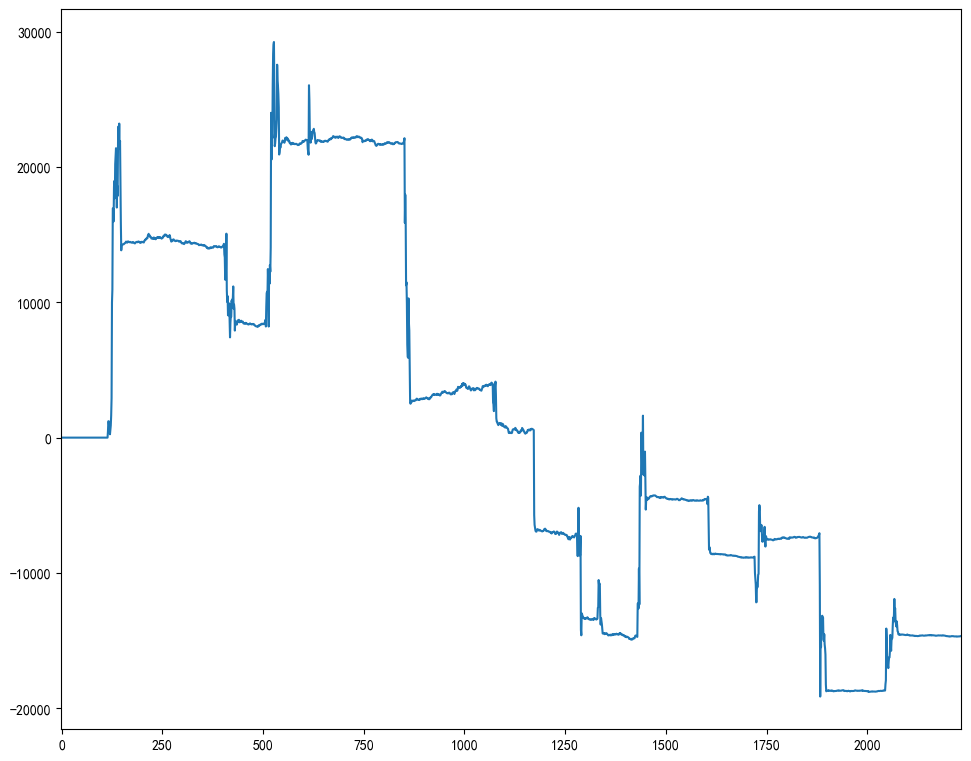

In [7]:
iodog.close()
q = Query(start_date, end_date, ktype=Query.DAY)
my_sys.run(stk, q)


#绘制资金收益曲线（净收益）
x = my_tm.get_profit_curve(stk.get_datetime_list(q), Query.DAY)
#x = my_tm.getFundsCurve(stk.getDatetimeList(q), KQuery.DAY) #总资产曲线
x = PRICELIST(x)
x.plot()

#回测统计
per = my_tm.get_performance()
per.statistics(my_tm, Datetime.now())
print(per.report())

<Axes: title={'center': '账户(SYS) 累积收益率'}>

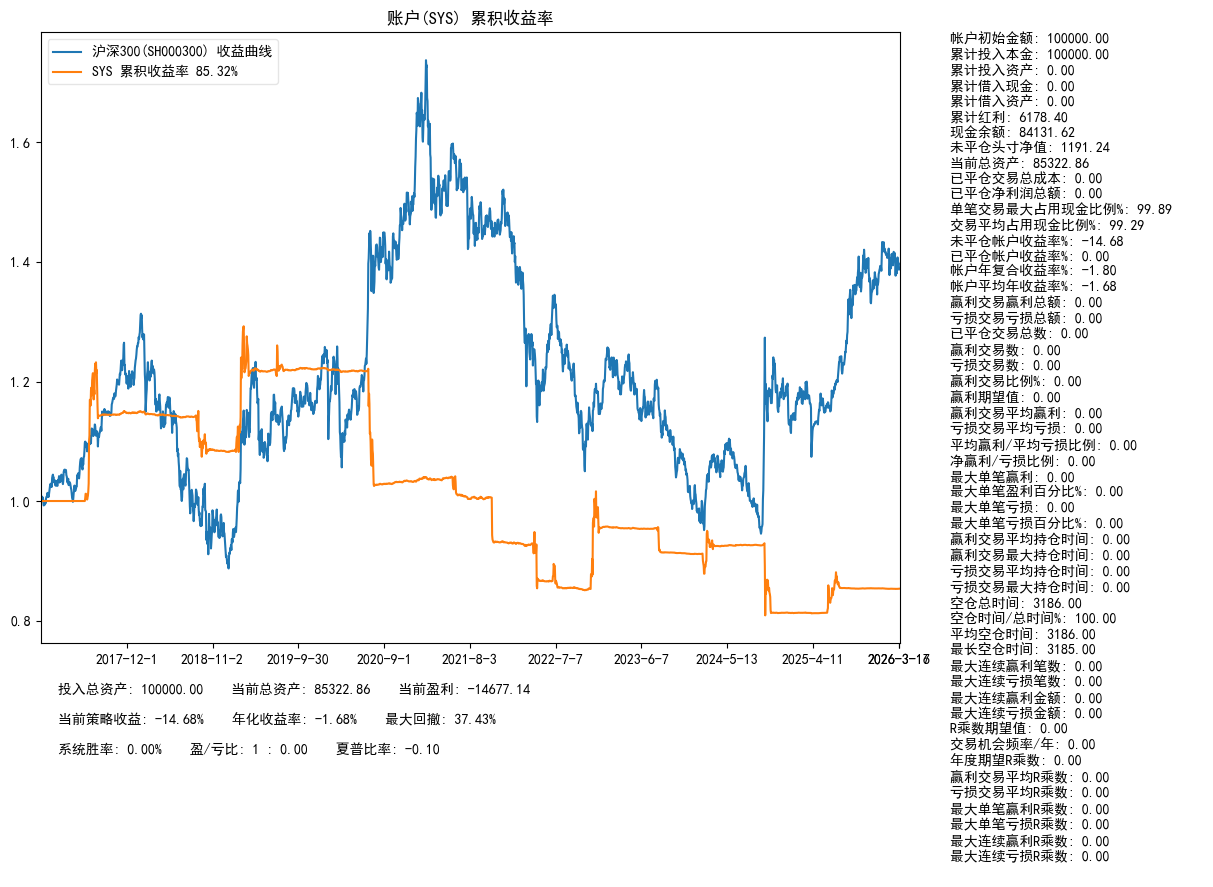

In [8]:
my_sys.performance()

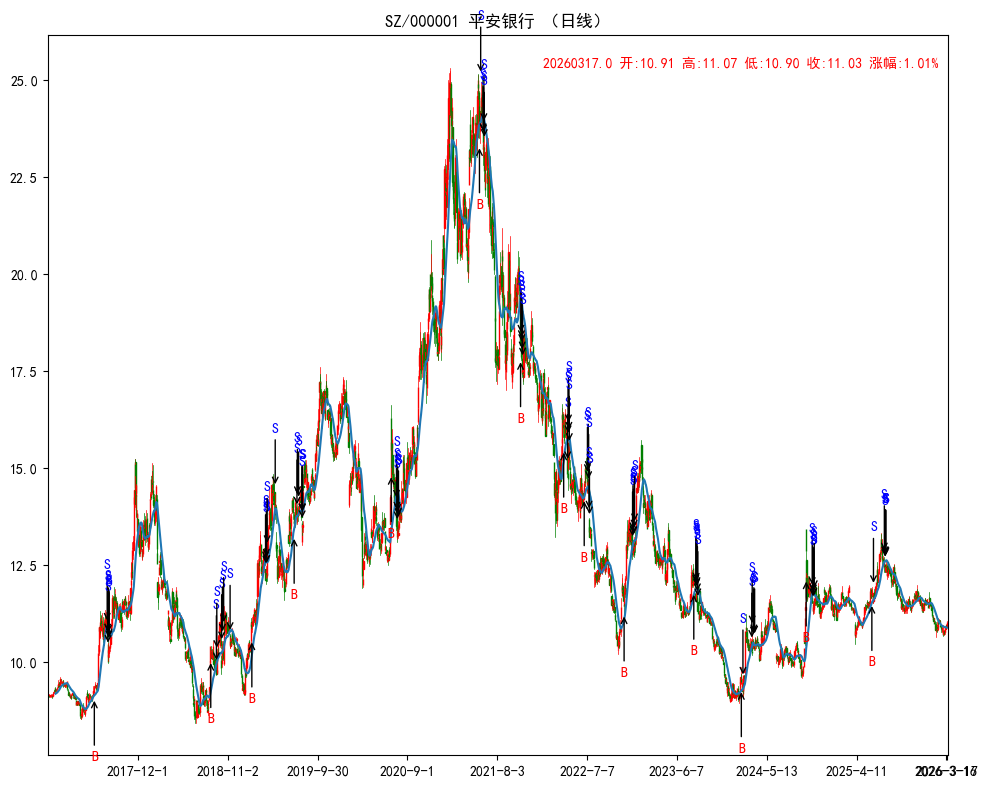

In [9]:
my_sys.plot()
MA(CLOSE(my_sys.to), 20).plot(new=False)